In [1]:
import os
import shutil
import random
import kagglehub
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing import image_dataset_from_directory

SEED = 42
random.seed(SEED)

LOCKED_CLASSES = [
    "Tomato___healthy",
    "Tomato___Early_blight",
    "Tomato___Late_blight",
    "Tomato___Leaf_Mold",
    "Potato___healthy",
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Pepper,_bell___healthy",
    "Pepper,_bell___Bacterial_spot",
    "Corn_(maize)___Common_rust_"
]

**Download Dataset**

In [2]:
path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")
print("Dataset path:", path)

base_dir = os.path.join(path, "plantvillage dataset", "color")
print(os.listdir(base_dir))
print("Number of classes:", len(os.listdir(base_dir)))

Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Dataset path: /kaggle/input/plantvillage-dataset
['Tomato___Late_blight', 'Tomato___healthy', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Potato___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Tomato___Early_blight', 'Tomato___Septoria_leaf_spot', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Strawberry___Leaf_scorch', 'Peach___healthy', 'Apple___Apple_scab', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Bacterial_spot', 'Apple___Black_rot', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Peach___Bacterial_spot', 'Apple___Cedar_apple_rust', 'Tomato___Target_Spot', 'Pepper,_bell___healthy', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Potato___Late_blight', 'Tomato___Tomato_mosaic_virus', 'Strawberry___healthy', 'Apple___healthy', 'Grape___Black_rot', 'Potato___Early_blight', 'Cherry_(including_sour)___hea

**Filter Classes**

In [3]:
filtered_dir = "data/filtered_data"
os.makedirs(filtered_dir, exist_ok=True)

for cls in LOCKED_CLASSES:
    src = os.path.join(base_dir, cls)
    dst = os.path.join(filtered_dir, cls)

    if os.path.exists(src):
        shutil.copytree(src, dst, dirs_exist_ok=True)

print("Filtering done!")

Filtering done!


**Split Dataset**

In [4]:
split_dir = "data/split_data"

train_dir = os.path.join(split_dir, "train")
val_dir = os.path.join(split_dir, "val")
test_dir = os.path.join(split_dir, "test")

for d in [train_dir, val_dir, test_dir]:
    os.makedirs(d, exist_ok=True)

def copy_images(images, src, dst):
    os.makedirs(dst, exist_ok=True)
    for img in images:
        shutil.copy(os.path.join(src, img), os.path.join(dst, img))

for cls in os.listdir(filtered_dir):
    class_path = os.path.join(filtered_dir, cls)
    images = os.listdir(class_path)

    train_imgs, temp = train_test_split(
        images,
        test_size=0.3,
        random_state=SEED
    )

    val_imgs, test_imgs = train_test_split(
        temp,
        test_size=0.5,
        random_state=SEED
    )

    copy_images(train_imgs, class_path, os.path.join(train_dir, cls))
    copy_images(val_imgs, class_path, os.path.join(val_dir, cls))
    copy_images(test_imgs, class_path, os.path.join(test_dir, cls))

print("Dataset split done!")

Dataset split done!


**Class Distribution**

In [5]:
def count_images(folder):
    counts = {}
    for cls in os.listdir(folder):
        cls_path = os.path.join(folder, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len(os.listdir(cls_path))
    return counts

train_counts = count_images(train_dir)
val_counts = count_images(val_dir)
test_counts = count_images(test_dir)

data = []
for cls in sorted(LOCKED_CLASSES):
    data.append({
        "Class": cls,
        "Train": train_counts.get(cls, 0),
        "Validation": val_counts.get(cls, 0),
        "Test": test_counts.get(cls, 0)
    })

df = pd.DataFrame(data)
print("Class Distribution:")
display(df)

Class Distribution:


,Class,Train,Validation,Test
0,Corn_(maize)___Common_rust_,834,179,179
1,"Pepper,_bell___Bacterial_spot",697,150,150
2,"Pepper,_bell___healthy",1034,222,222
3,Potato___Early_blight,700,150,150
4,Potato___Late_blight,700,150,150
5,Potato___healthy,106,23,23
6,Tomato___Early_blight,700,150,150
7,Tomato___Late_blight,1336,286,287
8,Tomato___Leaf_Mold,666,143,143
9,Tomato___healthy,1113,239,239


**Augmentation**

Augmentation pipeline created!
Found 7886 files belonging to 10 classes.
Saved: outputs/augmentation_samples.png


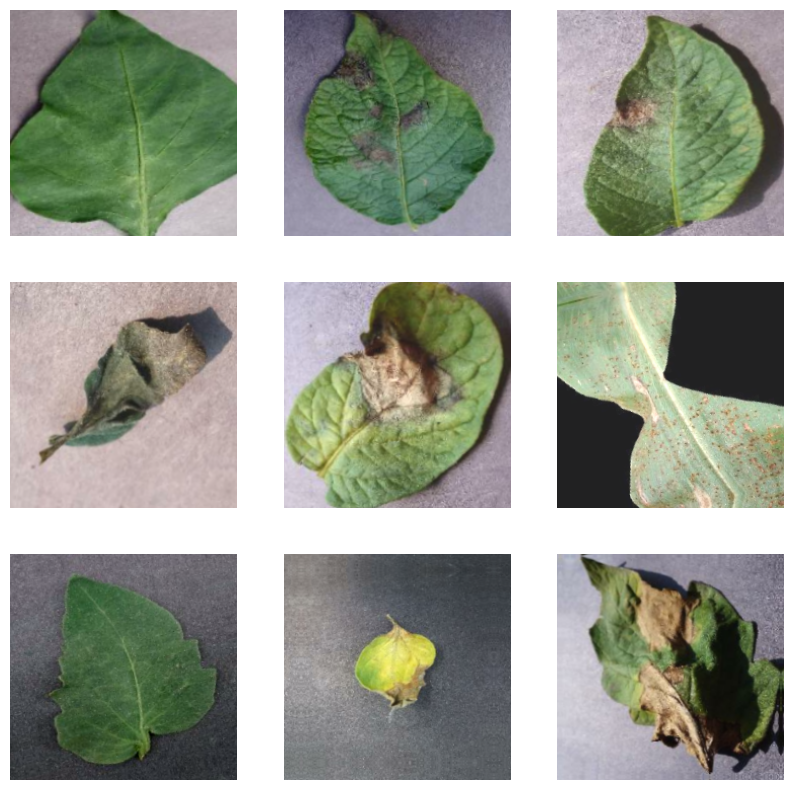

In [7]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.04),
    tf.keras.layers.RandomBrightness(0.2),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomZoom(0.2)
])

print("Augmentation pipeline created!")

train_ds = image_dataset_from_directory(
    train_dir,
    image_size=(224, 224),
    batch_size=9
)

for images, _ in train_ds.take(1):
    aug_images = data_augmentation(images)

    plt.figure(figsize=(10,10))

    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(aug_images[i].numpy().astype("uint8"))
        plt.axis("off")

    os.makedirs("outputs", exist_ok=True)
    plt.savefig("outputs/augmentation_samples.png")

print("Saved: outputs/augmentation_samples.png")

**Compare original vs augmented images**

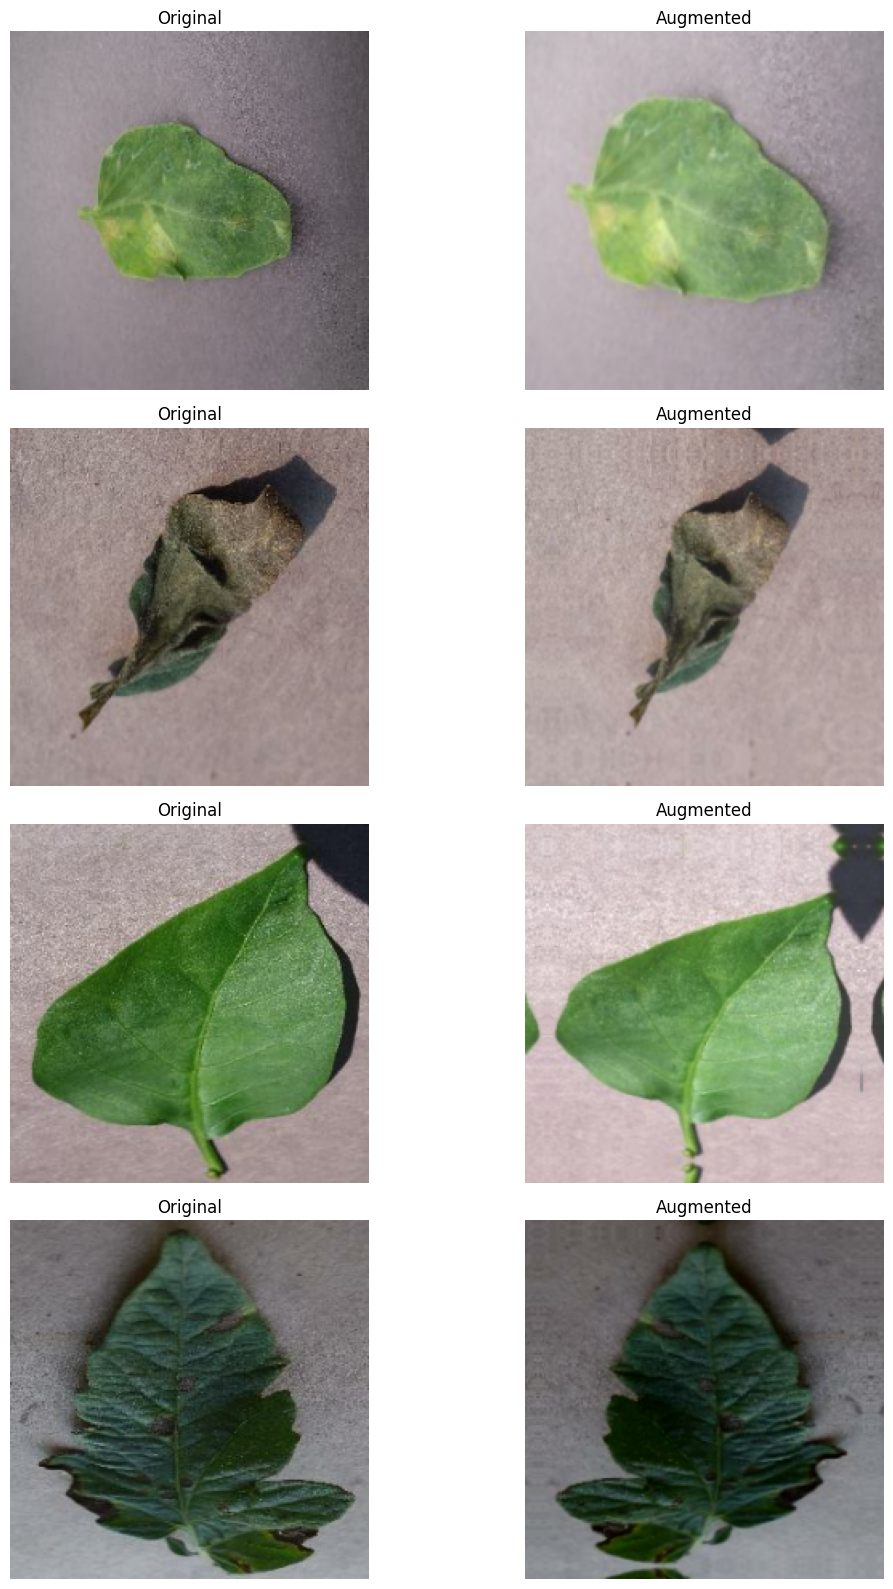

In [8]:
for images, _ in train_ds.take(1):

    aug_images = data_augmentation(images)

    plt.figure(figsize=(12, 16))

    for i in range(4):

        # Original image
        plt.subplot(4, 2, 2*i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title("Original")
        plt.axis("off")

        # Augmented image
        plt.subplot(4, 2, 2*i + 2)
        plt.imshow(aug_images[i].numpy().astype("uint8"))
        plt.title("Augmented")
        plt.axis("off")

    plt.tight_layout()
    plt.show()